In [6]:
#@title Run the cell below to install all requirements

!pip install biopython -q
!pip install phytreeviz -q

import os, math, itertools
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm

if not os.path.isdir("installations"):
  !mkdir installations
  %cd installations
  # taken from https://mafft.cbrc.jp/alignment/software/linuxportable.html
  !wget https://mafft.cbrc.jp/alignment/software/mafft-7.526-linux.tgz
  !tar xfz mafft-7.526-linux.tgz
  %cd ../

  !echo '#!/bin/bash' > /usr/local/bin/mafft
  !echo 'exec /content/installations/mafft-linux64/mafft.bat "$@"' >> /usr/local/bin/mafft
  !chmod +x /usr/local/bin/mafft

else:
  print('Seems that you already have installed the requirements.')
  print('To fully reset installation, press Runtime -> Disconnect and delete runtime, then reconnect and rerun this cell.')


def get_sequence_letters(arr: np.ndarray) -> np.ndarray:
  LETTERS = {float(i): v for i, v in enumerate('ACDEFGHIKLMNPQRSTVWYBZX')}
  result = np.vectorize(lambda x: LETTERS.get(x, '-'))(arr)
  return np.array(result)

Seems that you already have installed the requirements.
To fully reset installation, press Runtime -> Disconnect and delete runtime, then reconnect and rerun this cell.


# Task 2:

Are orthologs and paralogs really different, does the UPGMA algorithm cluster them correctly? Build a phylogenetic tree containing at least 12 hemoglobin alpha, 12 hemoglobin beta, and 4 other hemoglobin (theta etc.) sequences and see whether the tree will have hemoglobin types clearly separated.

**The tree should be visualized and Newick file should be generated for the tree.

Initial FASTA file, Newick tree, and tree image should be saved to your Github repository.**

# 1. Collect ortholog sequences

It is recommended to collect ortholog sequences using NCBI (Orthologs: all). If there is not enough orthologs, there may be more on the Ensembl or GeneCards pages.
- If you use databases other than NCBI, **make sure** that sequences contain `[organism=Homo sapiens]` line somewhere in their names (with the correct organism name instead of Homo sapiens). If needed, add manually, otherwise sequence name extraction may fail later.

It is recommended to include model organisms, such as *Mus musculus* (mouse) and *Danio rerio* (zebrafish).

Collect all sequences into a FASTA file with sequence names containing sequence identifiers and organism names.

FASTA files should then be uploaded into Notebook. You can print out names of sequences inside using this example code:

In [7]:
from Bio import SeqIO

fasta_filename = 'HB.faa'

for record in SeqIO.parse(fasta_filename, "fasta"):
  print(record.description)

NP_000549.1 HBA1 [organism=Homo sapiens] [GeneID=3039]
NP_001036091.1 HBA1 [organism=Pan troglodytes] [GeneID=732485]
XP_006050021.3 HBA1 [organism=Bubalus bubalis] [GeneID=102398439]
XP_040829605.1 HBA1 [organism=Ochotona curzoniae] [GeneID=121151821]
XP_003809438.1 HBA1 [organism=Pan paniscus] [GeneID=100983142]
XP_027796172.1 Hba1 [organism=Marmota flaviventris] [GeneID=114096799]
XP_044927985.1 HBA1 [organism=Mustela putorius furo] [GeneID=123389705]
XP_012661133.1 HBA1 [organism=Otolemur garnettii] [GeneID=100963520]
XP_004403127.1 HBA1 [organism=Odobenus rosmarus divergens] [GeneID=101372394]
XP_004628004.1 Hba1 [organism=Octodon degus] [GeneID=101591064]
XP_004652166.1 Hba1 [organism=Jaculus jaculus] [GeneID=101607114]
XP_007093709.2 HBA1 [organism=Panthera tigris] [GeneID=102969107]
NP_000509.1 HBB [organism=Homo sapiens] [GeneID=3043]
NP_150237.1 Hbb [organism=Rattus norvegicus] [GeneID=24440]
XP_002754937.1 HBB [organism=Callithrix jacchus] [GeneID=100410611]
XP_002822173.1 H

# 2. Align all sequences into MSA

MAFFT was already installed as one of requirements. To use it, Linux Bash commands are needed instead of Python code. Colab Notebooks allow to run Bash commands in any cell, however, each command should start with the `!` symbol.

The command below will print out information about installed MAFFT (note that `%` symbols are not part of commands):

In [8]:
!mafft --help

------------------------------------------------------------------------------
  MAFFT v7.526 (2024/Apr/26)
  https://mafft.cbrc.jp/alignment/software/
  MBE 30:772-780 (2013), NAR 30:3059-3066 (2002)
------------------------------------------------------------------------------
High speed:
  % mafft in > out
  % mafft --retree 1 in > out (fast)

High accuracy (for <~200 sequences x <~2,000 aa/nt):
  % mafft --maxiterate 1000 --localpair  in > out (% linsi in > out is also ok)
  % mafft --maxiterate 1000 --genafpair  in > out (% einsi in > out)
  % mafft --maxiterate 1000 --globalpair in > out (% ginsi in > out)

If unsure which option to use:
  % mafft --auto in > out

--op # :         Gap opening penalty, default: 1.53
--ep # :         Offset (works like gap extension penalty), default: 0.0
--maxiterate # : Maximum number of iterative refinement, default: 0
--clustalout :   Output: clustal format, default: fasta
--reorder :      Outorder: aligned, default: input order
--quiet :      

**Example**: generate an alignment file from given FASTA:

In [9]:
!mafft HB.faa > alignment.fasta

nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8192 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
    1 / 28
done.

Constructing a UPGMA tree (efffree=0) ... 
   20 / 28
done.

Progressive alignment 1/2... 
STEP    27 / 27  f
done.

Making a distance matrix from msa.. 
    0 / 28
done.

Constructing a UPGMA tree (efffree=1) ... 
   20 / 28
done.

Progressive alignment 2/2... 
STEP    27 / 27  f
done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich regions than previous versions.
To disable this change, add the --leavegapp

# Optional: visualize alignments

We will use two other Python packages to create our own visualization of alignments: Numpy and Seaborn. Numpy is a widely used packages for mathematical operations (usually imported as `np`), and Seaborn is for beautiful and easy plotting (usually imported as `sns`).

In [10]:
from Bio import AlignIO

filename = "alignment.HB.fasta"

alignment = AlignIO.read(filename, 'fasta').alignment

Custom functions below will help us extract the numerical alignment, as well as organism names (as there may be more information in the description and Y labels would be too long).

In [11]:
def convert_alignment_to_number_matrix(alignment) -> np.ndarray:
  numbers = {v: i for i, v in enumerate('ACDEFGHIKLMNPQRSTVWYBZX')}            # list all letters and assign a number to each; "X" is undefined aa.
  numbers['-'] = np.nan                                                        # for gaps, do not use colors (NaN means no value)
  alignment_numerical = []
  for i in range(len(alignment)):
    aligned_sequence = alignment[i]
    sequence_numerical = [numbers.get(letter) for letter in aligned_sequence]  # for each letter, get its number
    alignment_numerical.append(sequence_numerical)
  return np.array(alignment_numerical)

In [12]:
def get_organism_names(alignment) -> list[str]:
  organisms = []
  for i in range(len(alignment)):
    seq = alignment.sequences[i]                                     # get current sequence
    sequence_id = seq.id                                             # get sequence ID
    description = seq.description                                    # get sequence description
    organism = description.split('organism=')[1].split(']')[0]       # the name of the organism whould be after "organism=" and before closing ]
    short_name = f'{sequence_id} {organism}'                         # combine ID with organism name
    organisms.append(short_name)
  return organisms

Now these functions can be used to plot the alignment:

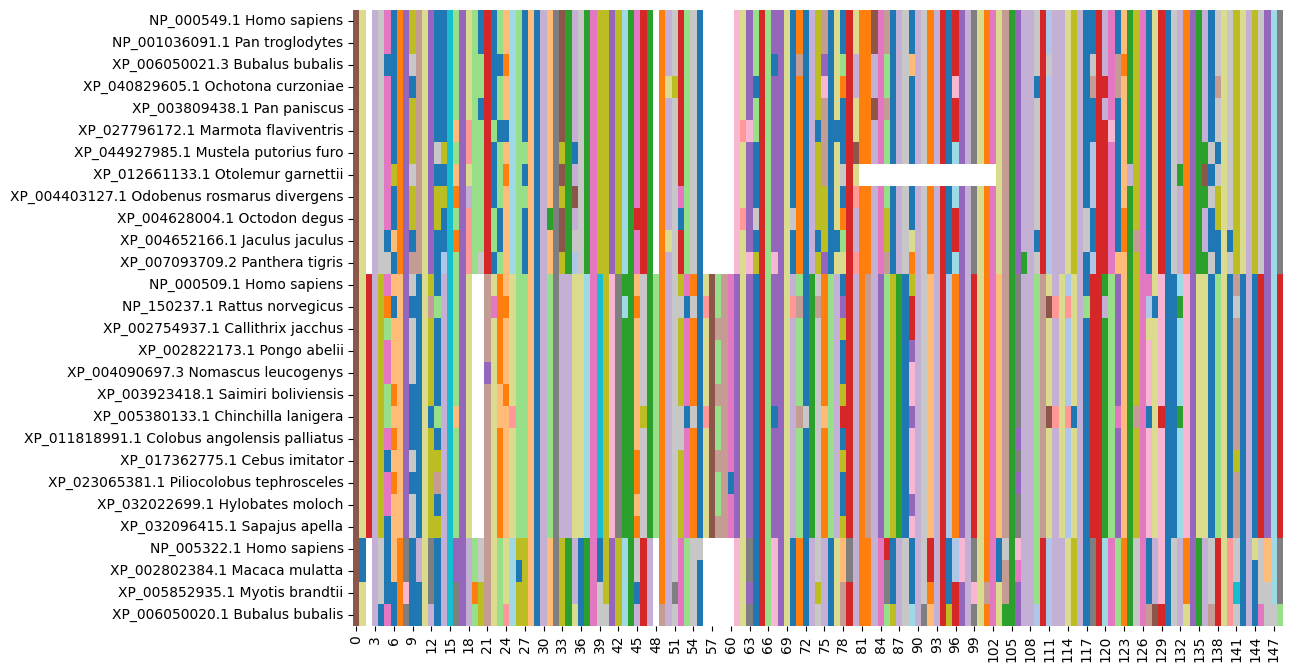

In [13]:
alignment_numerical = convert_alignment_to_number_matrix(alignment)
organisms = get_organism_names(alignment)

plt.figure(figsize=(12, 8))
sns.heatmap(alignment_numerical,            # matrix to visualize
            yticklabels=organisms,          # add organism names as ticks
            cbar=False,                     # hide meaningless colorbar
            cmap='tab20')                   # choose which color scheme to use
plt.show()

We can "zoom in" into the alignment by only plotting a certain part of it:

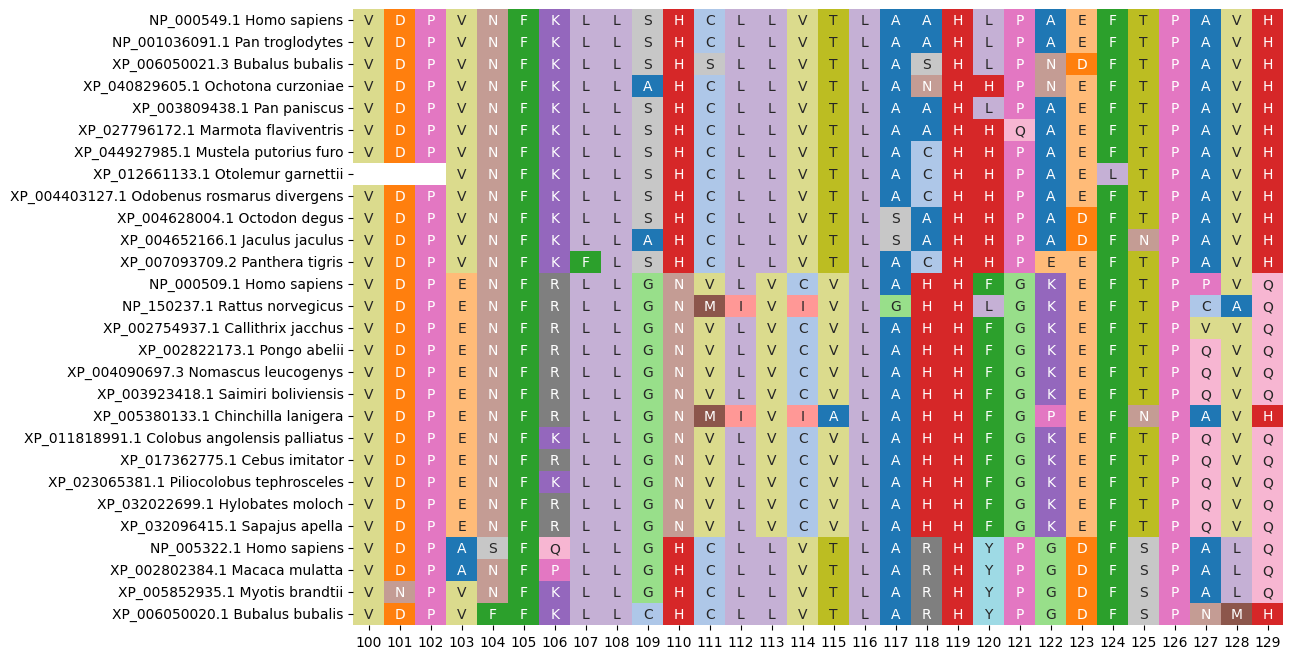

In [14]:
start_pos = 100      # choose your numbers
end_pos = 130        # choose your numbers

alignment_numerical_cut = alignment_numerical[:, start_pos:end_pos]

# to also visualize letters in the plot
alignment_letters = get_sequence_letters(alignment_numerical_cut)  # custom function defined during initial setup

plt.figure(figsize=(12, 8))
sns.heatmap(alignment_numerical_cut,
            yticklabels=organisms,                            # fill in the "..."
            xticklabels=np.arange(start_pos, end_pos),  # to have correct x ticks, not from 0
            annot=alignment_letters,                    # add annotations (letters)
            fmt='s',                                    # needed when plotting letters
            cbar=False, cmap='tab20')
plt.show()

# 4. Define a genetic distance model and obtain the distance matrix

To construct a phylogenetic tree from alignment using UPGMA, a distance matrix should be obtained first. And to do that, we need to decide how to calculate genetic distance between aligned sequences.

In this case, we work with protein sequences, so the obvious solution would be to use BLOSUM62. However, in BLOSUM62, bigger numbers mean higher similarity, but in distance matrix, bigger numbers should mean lesser similarity. BLOSUM62 matrix should be transformed. In phylogenetics, most usual transformation is:

$$D_{A,B}=e^{-\lambda\cdot B_{A,B}}$$

Where $B_{A,B}$ is the value coming from BLOSUM62 for amino acids A and B, and $D_{A,B}$ is the distance value. Usually, the scaling parameter $\lambda=0.5$. For BLOSUM62, it is specifically 0.3176.

**Transform the BLOSUM62 matrix to get its distance counterpart.**

In [15]:
from Bio import Align

blosum62 = Align.substitution_matrices.load("BLOSUM62")
blosum62_distance = np.exp(-0.3176 * blosum62)  # fill in the "..."

We also need to define the function to actually get genetic distances between pairs of sequences.

Note that BLOSUM matrices do not contain scores for gaps. Below, we will use a quite common approach called pairwise deletion. Gaps in this case are just ignored and not participating in score calculation.
- *Think: what problem it introduces?*

In [16]:
def get_genetic_distance(seq1: str, seq2: str, sub_matrix: np.ndarray,
                         alphabet: str = None) -> float:

  # keep some assertion statements inside for sanity checks
  assert len(seq1) == len(seq2), 'Provided sequences are not aligned!'
  if 'alphabet' in dir(sub_matrix):
    alphabet = sub_matrix.alphabet
  if isinstance(sub_matrix, np.ndarray):
    assert alphabet, 'For custom substitution matrix, it is required to also provide its alphabet'
    assert (len(alphabet) == sub_matrix.shape[0]) and (len(alphabet) == sub_matrix.shape[1]), 'Matrix is not square or does not correspond to the alphabet'
  else:
    raise ValueError('Substitution matrix has incorrect format.')

  # actual calculations
  score = 0                   # start with zero score
  aligned_pos = 0             # we will need to calculate the number of aligned aa. (everything except gaps)
  for i in range(len(seq1)):

    # get sequence amino acids (letters)
    letter1 = seq1[i]
    letter2 = seq2[i]

    # check if one of them is a gap
    if (letter1 == '-') or (letter2 == '-'):
      # fill in the "..." to have the pairwise deletion
      position_score = 0

    else:  # when there are no gaps, find amino acids in the substitution matrix and get row and column indices
      i1 = alphabet.find(letter1)
      i2 = alphabet.find(letter2)
      position_score = sub_matrix[i1][i2]
      aligned_pos += 1  # add 1 to the count of aligned amino acids

    # add position score to total score
    score += position_score

  return score / aligned_pos  # mean score

Not we need to apply this function to fill in the whole matrix:

In [17]:
def get_distance_matrix(alignment, substitution_matrix: np.ndarray,
                        alphabet: str = None) -> np.ndarray:
  n = len(alignment)
  distances = np.zeros((n, n))   # create empty matrix of correct shape (filled with zeros)

  for i, j in tqdm(itertools.combinations(range(n), r=2),                   # to save some time, only count all combinations
                   total=int(math.factorial(n)/(math.factorial(n-2)*2))):   # this is to help you see how many distances were already calculated

    seq1 = alignment[i]
    seq2 = alignment[j]

    # this is where we use genetic distance function
    distance = get_genetic_distance(seq1, seq2, sub_matrix=substitution_matrix,
                                    alphabet=alphabet)

    # input obtained distance into both halves of the matrix - fill in the "..."
    distances[i, j] = distance
    distances[j, i] = distance

  # delete numbers in the diagonal for easier calculations later
  for i in range(n):
    distances[i, i] = np.nan   # - fill in the "..."

  return distances

100%|██████████| 378/378 [00:02<00:00, 135.97it/s]


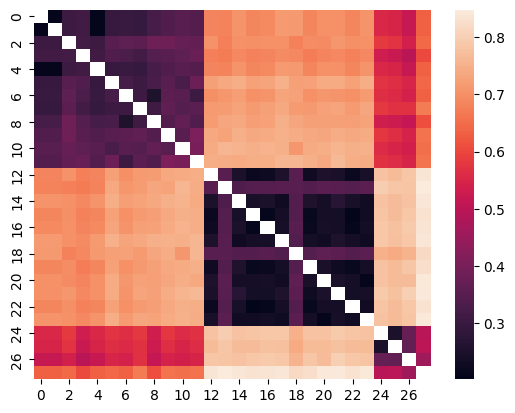

In [18]:
# not use the function - will take some time
dist_mat = get_distance_matrix(
    alignment,
    substitution_matrix=blosum62_distance    # fill in the "..."
)

# visualize the matrix
sns.heatmap(dist_mat);

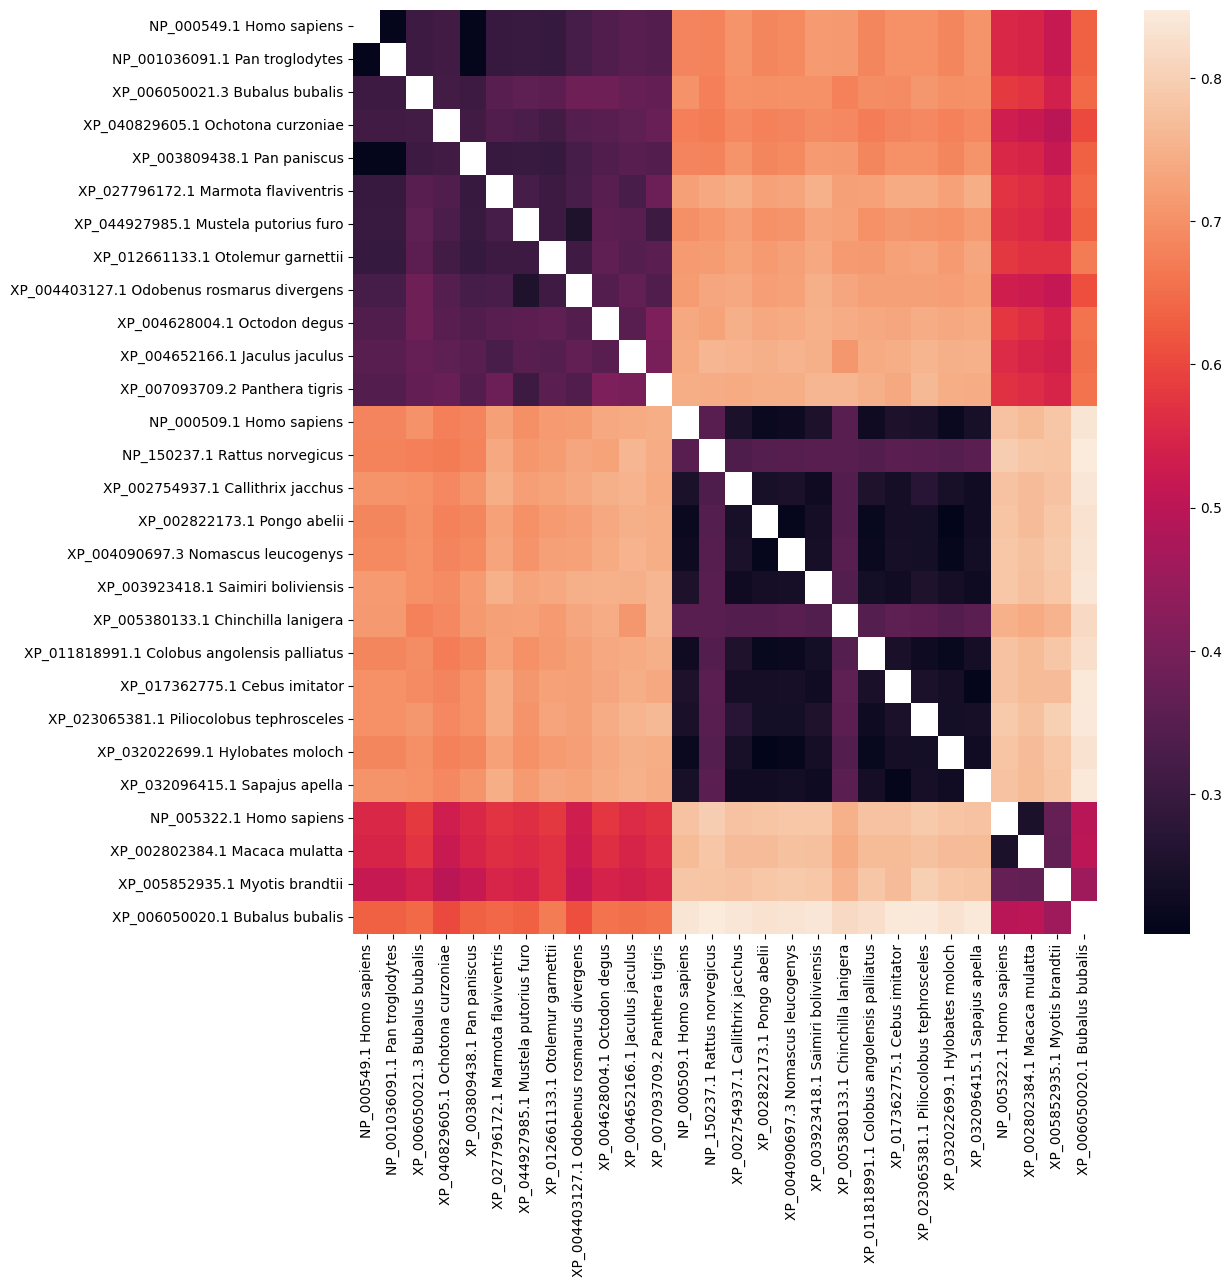

In [19]:
# visualize the matrix
plt.figure(figsize=(12, 12))
sns.heatmap(dist_mat,
            yticklabels=organisms,
            xticklabels=organisms);

# 5. Use UPGMA to obtain the phylogenetic tree

A graph should be constructed using the UPGMA method. First, we need to decide how to store the graph. One of simplest solutions would be to keep a list of all **edges**. An edge should contain names of two nodes it connects (parent and child in our case), and the weight of the edge (genetic distance):

`(sequence_A, sequence_B, 0.54)`

Leaf names (outer nodes) should have names of organisms from the alignment, but ancestor (parent) nodes don't have names. So, we can just generate numbers for them as names.

In [20]:
# create empty list to store our edges later
graph = []

# use our previously defined function to get organism names
names = get_organism_names(alignment)
names = [name.replace(' ', '_') for name in names]

# the first found parent (not the earliest ancestor!) will have name "0", next "1" and so on
parent = 0

# create a copy of the distance matrix in case we break something in it
mat = dist_mat.copy()

In [21]:
# there will be N-1 calculations where N is the number of sequences in alignment
for i in range(len(alignment)-1):
    # write the algorithm together with lecturer
    i1, i2 = np.unravel_index(np.nanargmin(mat), mat.shape)
    smallest_distance = mat[i1, i2]

    edge1 = (parent, names[i1], smallest_distance/2)
    edge2 = (parent, names[i2], smallest_distance/2)

    graph.append(edge1)
    graph.append(edge2)

    if mat.shape[0] <= 2:
      break

    mean_row = (mat[i1] + mat[i2]) / 2
    mat[i1] = mean_row
    mat[:, i1] = mean_row
    mat = np.delete(mat, i2, axis=0)
    mat = np.delete(mat, i2, axis=1)

    names[i1] = parent
    names.pop(i2)
    parent += 1

Next step is convert our custom format of phylogenetic tree into widely used Newick format.

Here, ask AI to write a function for you!

In [22]:
# paste the code from AI
from collections import defaultdict

def graph_to_newick(graph):

    # build parent -> children dictionary
    children = defaultdict(list)

    # keep track of which nodes appear as children
    child_nodes = set()

    for parent, child, dist in graph:
        children[parent].append((child, float(dist)))
        child_nodes.add(child)

    # find the root (node that never appears as a child)
    parents = set(children.keys())
    root_candidates = parents - child_nodes
    root = list(root_candidates)[0]

    # recursive function to build the Newick tree
    def build(node):

        # if node is a leaf (organism name)
        if node not in children:
            return str(node)

        parts = []
        for child, dist in children[node]:
            subtree = build(child)
            parts.append(f"{subtree}:{dist}")

        return "(" + ",".join(parts) + ")"

    newick = build(root) + ";"
    return newick

Use it to generate the Newick string:

In [23]:
newick_string = graph_to_newick(graph)  # the name of generated function

# write the string into a new text file
with open('tree.nwk', 'w') as f:
  f.write(newick_string)

# Newick files can be plotted using Biopython:

In [24]:
from Bio import Phylo
newick_tree = Phylo.read('tree.nwk', format='newick')
Phylo.draw_ascii(newick_tree)

                                  _ NP_000549.1_Homo_sapiens
                                _|
                             __| |_ NP_001036091.1_Pan_troglodytes
                            |  |
                          __|  |_ XP_003809438.1_Pan_paniscus
                         |  |
                       __|  |__ XP_012661133.1_Otolemur_garnettii
                      |  |
                    __|  |__ XP_027796172.1_Marmota_flaviventris
                   |  |
                   |  |   __ XP_044927985.1_Mustela_putorius_furo
                 __|  |__|
                |  |     |__ XP_004403127.1_Odobenus_rosmarus_dive...
                |  |
              __|  |__ XP_007093709.2_Panthera_tigris
             |  |
             |  |   __ XP_006050021.3_Bubalus_bubalis
        _____|  |__|
       |     |     |__ XP_040829605.1_Ochotona_curzoniae
       |     |
       |     |   __ XP_004628004.1_Octodon_degus
       |     |__|
  _____|        |__ XP_004652166.1_Jaculus_jaculus
 |     |


A better visualization can be obtained by using the Phytreeviz package (installed during the first step):

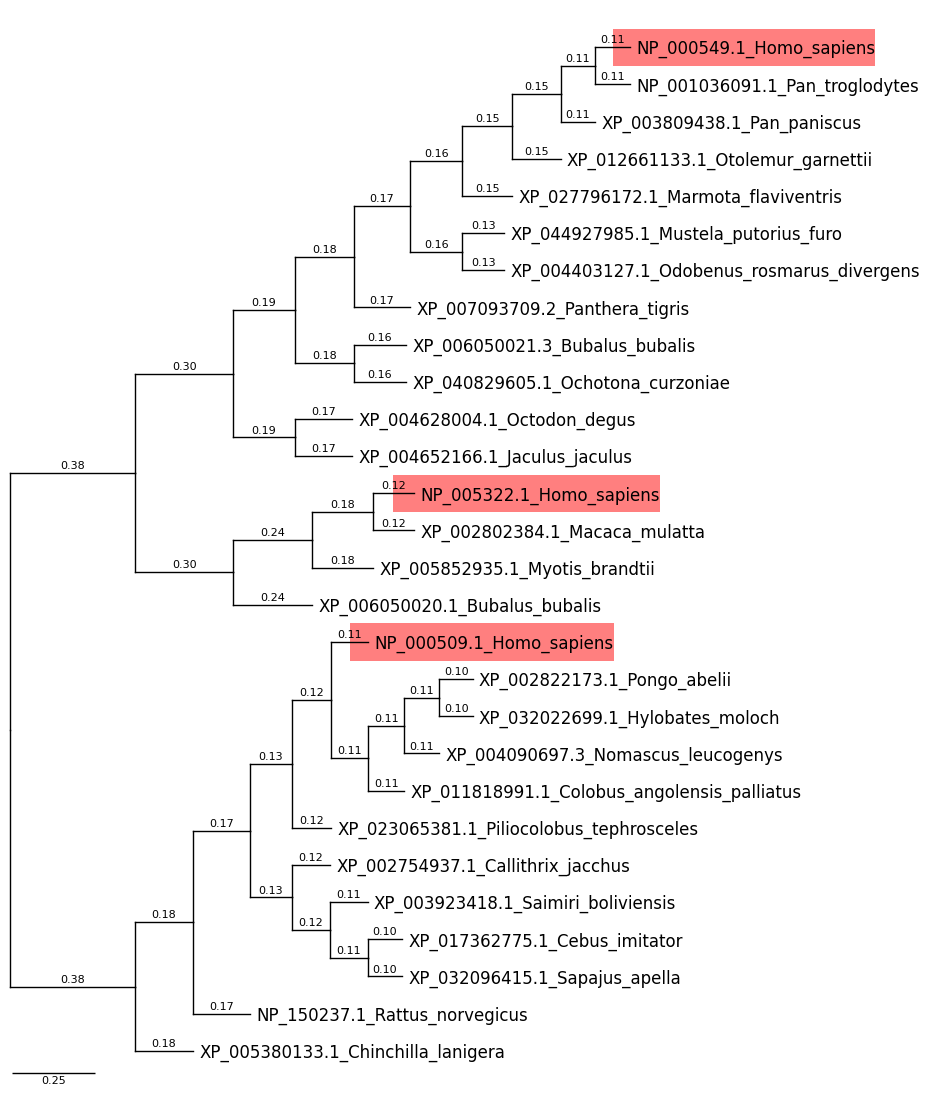

In [25]:
from phytreeviz import TreeViz

with open('tree.nwk', 'r') as f:
  newick_string = f.read()

tree = TreeViz(newick_string, format='newick')
tree.show_branch_length()
tree.show_scale_bar()
tree.highlight('NP_000549.1_Homo_sapiens', color='red')
tree.highlight('NP_000509.1_Homo_sapiens', color='red')
tree.highlight('NP_005322.1_Homo_sapiens', color='red')
tree.plotfig()
plt.show()